In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import zipfile for extraction
import zipfile

# Set the path to your new zip file in Google Drive
zip_path = "/content/drive/MyDrive/kali.zip"

# Set extraction folder
extract_path = "/content/kali"

# Extract the zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("UTSWGlioma extracted successfully")

UTSWGlioma extracted successfully


In [ ]:
import os

print(os.listdir("/content/kali"))

['kali']


In [ ]:
import os

base_path = "/content/kali/kali"

print(os.listdir(base_path))

['BT0141', 'BT0090', 'BT0021', 'BT0104', 'BT0075', 'BT0068', 'BT0059', 'BT0050', 'BT0091', 'BT0147', 'BT0041', 'BT0148', 'BT0078', 'BT0095', 'BT0102', 'BT0128', 'BT0013', 'BT0096', 'BT0103', 'BT0126', 'BT0107', 'BT0023', 'BT0065', 'BT0033', 'BT0030', 'BT0149', 'BT0029', 'BT0119', 'BT0024', 'BT0083', 'BT0084', 'BT0136', 'BT0053', 'BT0007', 'BT0079', 'BT0034', 'BT0008', 'BT0018', 'BT0003', 'BT0062', 'BT0108', 'BT0035', 'BT0020', 'BT0130', 'BT0089', 'BT0143', 'BT0055', 'BT0005', 'BT0124', 'BT0120', 'BT0112', 'BT0001', 'BT0045', 'BT0129', 'BT0081', 'BT0146', 'BT0086', 'BT0115', 'BT0009', 'BT0099', 'BT0011', 'BT0061', 'BT0145', 'BT0139', 'BT0113', 'BT0087', 'BT0036', 'BT0060', 'BT0027', 'BT0150', 'BT0133', 'BT0002', 'BT0070', 'BT0015', 'BT0142', 'BT0137', 'BT0042', 'BT0066', 'BT0026', 'BT0063', 'BT0144', 'BT0019', 'BT0076', 'BT0138', 'BT0101', 'BT0048', 'BT0122', 'BT0127', 'BT0140']


In [ ]:
import os

patient_path = "/content/kali/kali/BT0001"
print(os.listdir(patient_path))

['brain_t1.nii.gz', 'brain_t1_ants.nii.gz', 'brain_fl_ants.nii.gz', 'brain_t1ce_ants.nii.gz', 'tumorseg_manual_correction.nii.gz', 'tumorseg_FeTS.nii.gz', 'brain_t2_ants.nii.gz', 'brain_t2.nii.gz', 'brain_t1ce.nii.gz', 'rtumorseg_manual_correction.nii.gz', 'brain_flair.nii.gz']


Shape: (240, 240, 155)


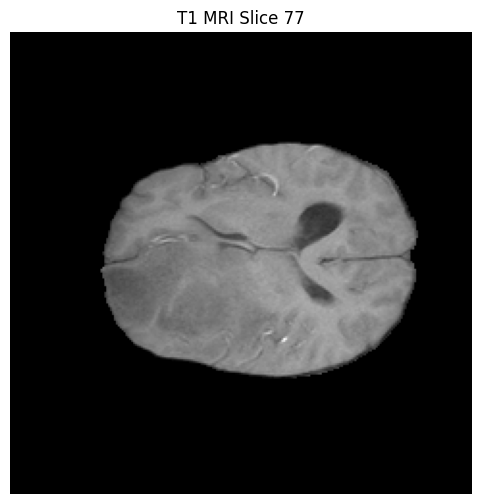

In [ ]:
# Import required libraries
import nibabel as nib
import matplotlib.pyplot as plt
import os

# Set patient folder
patient_path = "/content/kali/kali/BT0001"

# Choose one MRI modality
file_path = os.path.join(patient_path, "brain_t1.nii.gz")

# Load MRI file
img = nib.load(file_path)

# Convert MRI to numpy array
data = img.get_fdata()

# Print image shape
print("Shape:", data.shape)

# Select middle slice
slice_idx = data.shape[2] // 2

# Display the slice
plt.figure(figsize=(6, 6))
plt.imshow(data[:, :, slice_idx], cmap="gray")
plt.title(f"T1 MRI Slice {slice_idx}")
plt.axis("off")
plt.show()

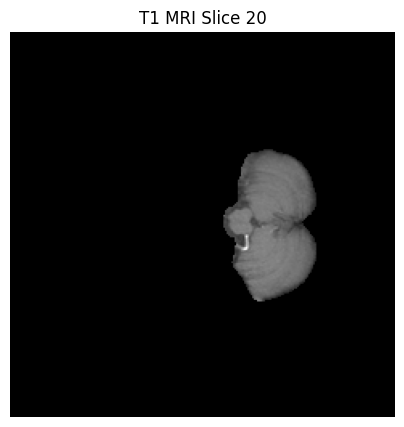

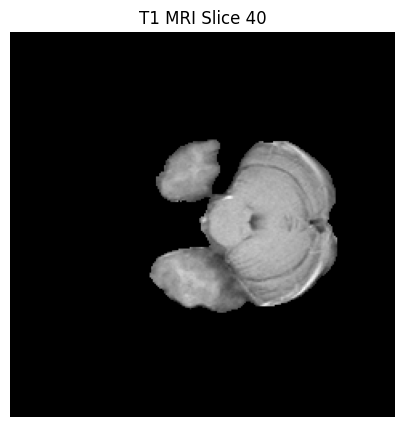

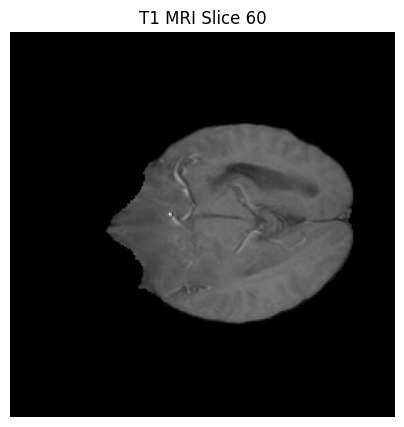

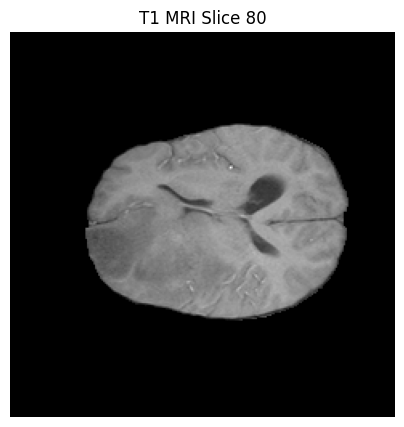

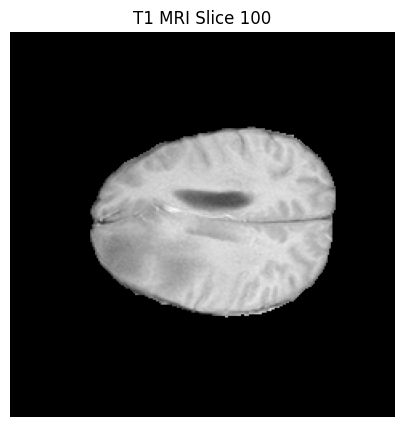

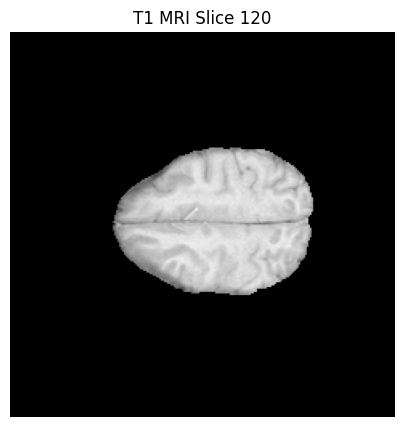

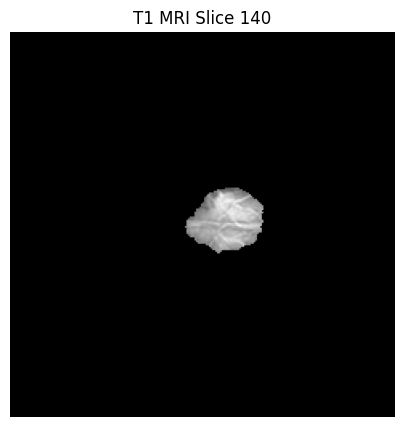

In [ ]:
# Display multiple slices
for i in range(20, data.shape[2], 20):
    plt.figure(figsize=(5, 5))
    plt.imshow(data[:, :, i], cmap="gray")
    plt.title(f"T1 MRI Slice {i}")
    plt.axis("off")
    plt.show()

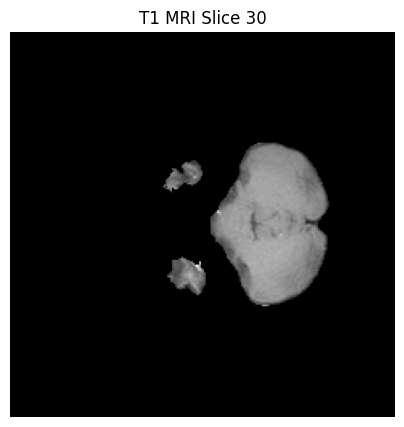

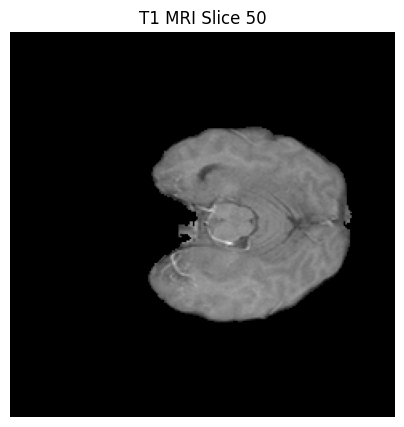

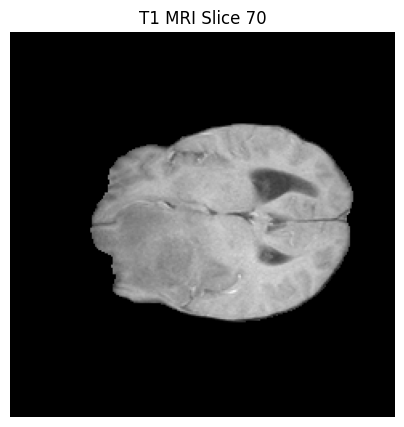

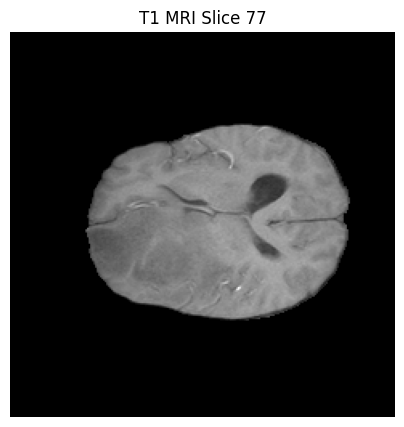

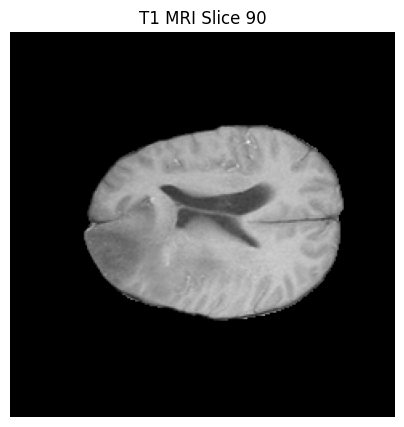

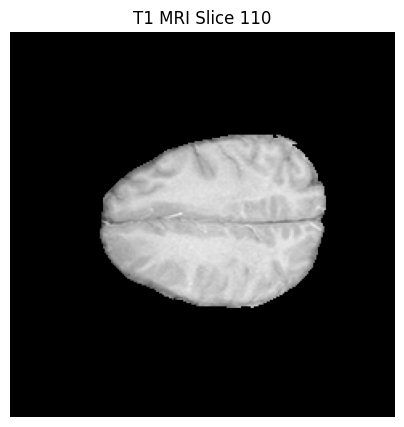

In [ ]:
# Show several slices from the MRI volume
for i in [30, 50, 70, 77, 90, 110]:
    plt.figure(figsize=(5, 5))
    plt.imshow(data[:, :, i], cmap="gray")
    plt.title(f"T1 MRI Slice {i}")
    plt.axis("off")
    plt.show()

In [ ]:
import os

base_path = "/content/kali/kali"
patients = [p for p in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, p))]

print("Total patients:", len(patients))
print("First 10 patients:", patients[:10])

Total patients: 89
First 10 patients: ['BT0141', 'BT0090', 'BT0021', 'BT0104', 'BT0075', 'BT0068', 'BT0059', 'BT0050', 'BT0091', 'BT0147']


In [ ]:
import os
import nibabel as nib

base_path = "/content/kali/kali"
patient_path = os.path.join(base_path, "BT0001")

# Load mask
mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")
mask_img = nib.load(mask_path)
mask_data = mask_img.get_fdata()

print("Mask shape:", mask_data.shape)

# Find slice with maximum tumor area
tumor_areas = [mask_data[:, :, i].sum() for i in range(mask_data.shape[2])]
best_mask_slice = tumor_areas.index(max(tumor_areas))

print("Best tumor slice (mask):", best_mask_slice)

Mask shape: (74, 93, 63)
Best tumor slice (mask): 36


In [ ]:
import os
import nibabel as nib
import pandas as pd

base_path = "/content/kali/kali"
results = []

patients = [p for p in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, p))]

for patient in patients:
    patient_path = os.path.join(base_path, patient)
    mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")

    try:
        mask_img = nib.load(mask_path)
        mask_data = mask_img.get_fdata()

        tumor_areas = [mask_data[:, :, i].sum() for i in range(mask_data.shape[2])]
        best_mask_slice = tumor_areas.index(max(tumor_areas))
        max_area = max(tumor_areas)

        results.append([patient, mask_data.shape, best_mask_slice, max_area])

    except Exception as e:
        results.append([patient, "ERROR", "ERROR", str(e)])

df = pd.DataFrame(results, columns=["Patient", "Mask Shape", "Best Tumor Slice", "Max Tumor Area"])
print(df.head())
print("Total processed:", len(df))

  Patient       Mask Shape Best Tumor Slice Max Tumor Area
0  BT0141     (34, 43, 48)               23         2433.0
1  BT0090  (240, 240, 155)               72         6418.0
2  BT0021  (240, 240, 155)               90         6090.0
3  BT0104     (62, 85, 72)               45         7496.0
4  BT0075     (45, 65, 46)               23         3090.0
Total processed: 89


MRI shape: (240, 240, 155)
Resampled mask shape: (240, 240, 155)
Best aligned slice: 87


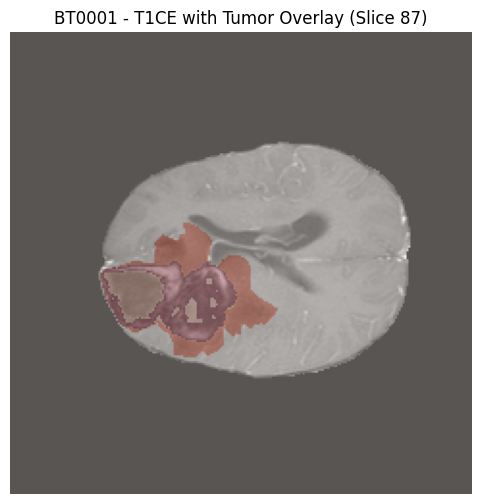

In [ ]:
import matplotlib.pyplot as plt
from nibabel.processing import resample_from_to

base_path = "/content/kali/kali"
patient_path = os.path.join(base_path, "BT0001")

# Load MRI
mri_path = os.path.join(patient_path, "brain_t1ce.nii.gz")
mri_img = nib.load(mri_path)
mri_data = mri_img.get_fdata()

# Load mask
mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")
mask_img = nib.load(mask_path)

# Resample mask to MRI space
mask_resampled = resample_from_to(mask_img, mri_img, order=0)
mask_resampled_data = mask_resampled.get_fdata()

# Find best aligned slice
tumor_areas = [mask_resampled_data[:, :, i].sum() for i in range(mask_resampled_data.shape[2])]
best_slice = tumor_areas.index(max(tumor_areas))

print("MRI shape:", mri_data.shape)
print("Resampled mask shape:", mask_resampled_data.shape)
print("Best aligned slice:", best_slice)

# Display overlay
plt.figure(figsize=(6, 6))
plt.imshow(mri_data[:, :, best_slice], cmap="gray")
plt.imshow(mask_resampled_data[:, :, best_slice], cmap="Reds", alpha=0.35)
plt.title(f"BT0001 - T1CE with Tumor Overlay (Slice {best_slice})")
plt.axis("off")
plt.show()

# ADD FEATURE EXTRACTION (IMPORTANT)

In [ ]:
import numpy as np

def extract_features(image, mask=None):
    # Tumor region
    if mask is not None and np.sum(mask) > 0:
        pixels = image[mask > 0]
    # Non-tumor: use full slice
    else:
        pixels = image.flatten()

    if pixels.size == 0:
        return None

    return {
        "mean": float(np.mean(pixels)),
        "std": float(np.std(pixels)),
        "max": float(np.max(pixels)),
        "area": int(pixels.size)
    }

In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to

data_list = []

for patient in patients:
    patient_path = os.path.join(base_path, patient)

    mri_path  = os.path.join(patient_path, "brain_t1ce.nii.gz")
    mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")

    # use only patients with both files
    if not (os.path.exists(mri_path) and os.path.exists(mask_path)):
        continue

    try:
        mri = nib.load(mri_path)
        mri_data = mri.get_fdata()

        mask = nib.load(mask_path)
        mask_resampled = resample_from_to(mask, mri, order=0)
        mask_data = mask_resampled.get_fdata()

        tumor_areas = np.array([mask_data[:, :, i].sum() for i in range(mask_data.shape[2])])

        # ---------- TUMOR (label=1) ----------
        tumor_slices = np.where(tumor_areas > 0)[0]
        for s in tumor_slices[:3]:  # max 3 per patient
            feats = extract_features(mri_data[:, :, s], mask_data[:, :, s])
            if feats:
                feats["label"] = 1
                feats["patient"] = patient
                data_list.append(feats)

        # ---------- NON-TUMOR (label=0) ----------
        non_tumor_slices = np.where(tumor_areas == 0)[0]
        if len(non_tumor_slices) > 0:
            step = max(1, len(non_tumor_slices)//3)
            for s in non_tumor_slices[::step][:3]:
                feats = extract_features(mri_data[:, :, s], None)
                if feats:
                    feats["label"] = 0
                    feats["patient"] = patient
                    data_list.append(feats)

    except Exception as e:
        print(f"Error in {patient}: {e}")

df = pd.DataFrame(data_list)

print("Dataset shape:", df.shape)
print("\nLabel distribution:\n", df["label"].value_counts())

Dataset shape: (468, 6)

Label distribution:
 label
1    234
0    234
Name: count, dtype: int64


In [ ]:
# 🔥 Remove leakage feature
df = df.drop(columns=["area"])

In [ ]:
X = df.drop(["label", "patient"], axis=1)
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

unique_patients = df["patient"].unique()

train_p, test_p = train_test_split(unique_patients, test_size=0.3, random_state=42)

train_df = df[df["patient"].isin(train_p)]
test_df = df[df["patient"].isin(test_p)]

X_train = train_df.drop(["label", "patient"], axis=1)
y_train = train_df["label"]

X_test = test_df.drop(["label", "patient"], axis=1)
y_test = test_df["label"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9930555555555556

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        72
           1       0.99      1.00      0.99        72

    accuracy                           0.99       144
   macro avg       0.99      0.99      0.99       144
weighted avg       0.99      0.99      0.99       144



In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import numpy as np

X = df.drop(["label", "patient"], axis=1)
y = df["label"]
groups = df["patient"]

gkf = GroupKFold(n_splits=5)

scores = []
for train_idx, val_idx in gkf.split(X, y, groups):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    model = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X_tr, y_tr)
    scores.append(model.score(X_val, y_val))

print("GroupKFold CV accuracy:", np.mean(scores))

GroupKFold CV accuracy: 0.9663888888888887


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9383173076923077


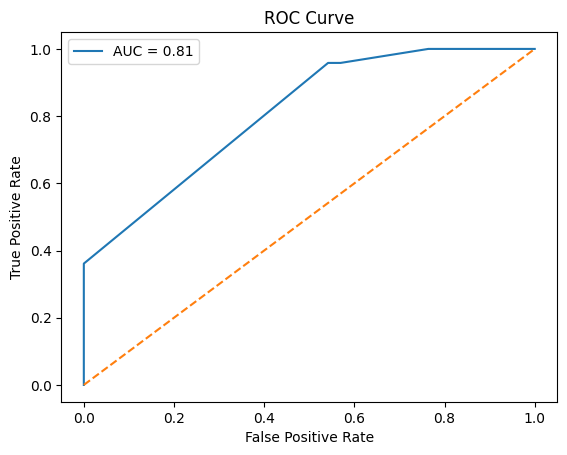

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

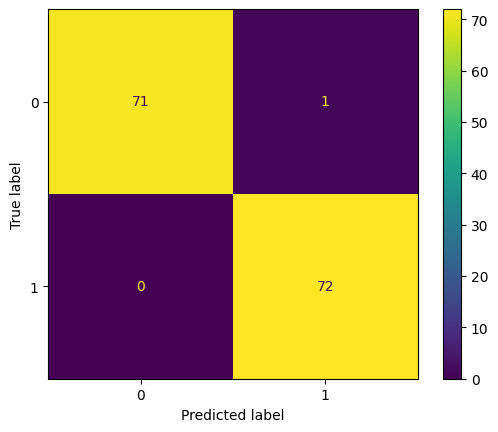

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

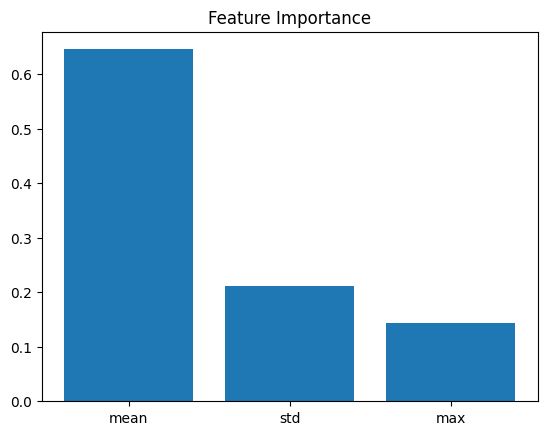

In [ ]:
import matplotlib.pyplot as plt

features = ["mean", "std", "max"]
importances = model.feature_importances_

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()